# Projet Informatique 2026

**Intitulé :** Prévision des prix de l'électricité sur le marché SPOT

---

## Présentation de l'entreprise

NW est un acteur reconnu du stockage d'électricité grâce à sa solution de stockage par batterie, la JBox. A ce jour, NW a installé près de 1000 Jbox en France et en Finlande ce qui représente 1.8 GWh (soit environ 2 réacteurs nucléaires). La filiale de NW en charge de l'agrégation a pour objectif d'acheter et de vendre l'électricité stockée par les batteries sur les marchés.

---

## Présentation du sujet

Le marché SPOT est la place centrale pour acheter et vendre de l'électricité. Chaque acteur — fournisseur, producteur ou exploitant de batteries — soumet chaque jour avant 13h ses offres d'achat et de vente pour le lendemain, en précisant les volumes souhaités et le prix qu'il est prêt à accepter. Le prix de marché est ensuite fixé par les bourses européennes de l'énergie de manière à équilibrer l'offre et la demande.

---

## Objectif

Afin d'optimiser les revenus de NW sur le marché SPOT, nous proposons aux élèves de développer un algorithme de prédiction des prix du marché. Cet algorithme s'appuiera sur les prix historiques ainsi que sur des variables exogènes à identifier par les élèves.

Les données exogènes seront soit mises à disposition via l'entrepôt de données de NW, soit récupérées directement en ligne par les élèves à partir de sources open data si nécessaire.

La zone de prédiction initiale est la **Finlande**, avec une possible extension à la France et aux autres pays nordiques.

Toute approche méthodologique sera la bienvenue : machine learning, deep learning, analyse de sensibilité, etc.

---

## Critère de réussite

La performance du projet sera évaluée en comparant les revenus générés avec une batterie de **2 MWh / 1 MW** par une stratégie de trading basée sur les prix prédits à ceux qu'aurait permis une connaissance parfaite des prix.

---

## Ressources Utiles

### Corpus de sources

- Basics of the Power Markets   -   https://www.epexspot.com/en/basicspowermarket
- Coupling of Day-ahead(=Spot) Markets   -   https://www.entsoe.eu/network_codes/cacm/implementation/sdac/
- Electricity maps   -   https://app.electricitymaps.com/map/zone/FR/live/fifteen_minutes?signal=electricity-price
- IEA energy & electricity in Finland   -   https://www.iea.org/countries/finland
- entso-e transparency   -   https://transparency.entsoe.eu/
- ...

### Données NW

In [1]:
import re
import numpy as np
import pandas as pd
from datetime import date
from google.cloud import bigquery
import warnings
warnings.filterwarnings("ignore", message="BigQuery Storage module not found")

pd.options.plotting.backend = "plotly"
bq_client = bigquery.Client()

In [2]:
# List all the available tables in the warehouse matching a specific regex

def search_tables(project, dataset_id, keyword):
    dataset_ref = bq_client.dataset(dataset_id, project=project)
    pattern = re.compile(keyword, re.IGNORECASE)
    rows = []
    for table in bq_client.list_tables(dataset_ref):
        if pattern.search(table.table_id):
            rows.append({
                "dataset": dataset_id,
                "table":   table.table_id,
                "type":    table.table_type,
                "full_id": f"{project}.{dataset_id}.{table.table_id}",
            })
    df_tables = pd.DataFrame(rows)
    print(f"Found {len(df_tables)} matching tables")
    return df_tables

In [4]:
project = "warehouse-390509"
dataset_id = "Public_Data"
keyword = "temperature"

search_tables(project, dataset_id, keyword)

Found 4 matching tables


,dataset,table,type,full_id
0,Public_Data,fingrid_pss_temperature_helsinki,TABLE,warehouse-390509.Public_Data.fingrid_pss_tempe...
1,Public_Data,fingrid_pss_temperature_jyvaskyla,TABLE,warehouse-390509.Public_Data.fingrid_pss_tempe...
2,Public_Data,fingrid_pss_temperature_oulu,TABLE,warehouse-390509.Public_Data.fingrid_pss_tempe...
3,Public_Data,fingrid_pss_temperature_rovaniemi,TABLE,warehouse-390509.Public_Data.fingrid_pss_tempe...


In [10]:
table_id = "fingrid_pss_temperature_helsinki"

QUERY = f"""
    SELECT *
    FROM `{project}.{dataset_id}.{table_id}`
"""

df = bq_client.query(QUERY, location="eu").to_dataframe()
df['start_time'] = pd.to_datetime(df['start_time'])

# 2. Extraire uniquement la date (sans l'heure) pour pouvoir grouper par jour
df['jour'] = df['start_time'].dt.date

# 3. Grouper par 'jour' et calculer la moyenne de la colonne 'value'
df_moyenne = df.groupby('jour')['value'].mean().reset_index()

# 4. Renommer la colonne pour plus de clarté (optionnel)
df_moyenne = df_moyenne.rename(columns={'value': 'temperature_moyenne'})

# Afficher le résultat
print(df_moyenne.tail(10))
df

           jour  temperature_moyenne
906  2026-06-24            16.917574
907  2026-06-25            18.411841
908  2026-06-26            18.954854
909  2026-06-27            21.855459
910  2026-06-28            21.430983
911  2026-06-29            21.999248
912  2026-06-30            24.361507
913  2026-07-01            22.601308
914  2026-07-02            18.647042
915  2026-07-03            17.219219


,start_time,end_time,value,dataset_id,ingestion_date,jour
0,2025-12-26 22:57:00+00:00,2025-12-26 23:00:00+00:00,1.9184,178,NaT,2025-12-26
1,2026-02-02 02:12:00+00:00,2026-02-02 02:15:00+00:00,-27.1680,178,NaT,2026-02-02
2,2026-02-02 02:21:00+00:00,2026-02-02 02:24:00+00:00,-27.1630,178,NaT,2026-02-02
3,2026-02-02 02:15:00+00:00,2026-02-02 02:18:00+00:00,-27.1630,178,NaT,2026-02-02
4,2026-02-02 02:27:00+00:00,2026-02-02 02:30:00+00:00,-27.1630,178,NaT,2026-02-02
...,...,...,...,...,...,...
472447,2024-10-11 02:00:00+00:00,2024-10-11 02:03:00+00:00,14.6290,178,NaT,2024-10-11
472448,2024-10-11 01:45:00+00:00,2024-10-11 01:48:00+00:00,14.6290,178,NaT,2024-10-11
472449,2024-10-11 01:27:00+00:00,2024-10-11 01:30:00+00:00,14.6290,178,NaT,2024-10-11
472450,2024-10-11 01:51:00+00:00,2024-10-11 01:54:00+00:00,14.6290,178,NaT,2024-10-11


In [6]:
today = date.today()
zone = 'FI'

QUERY = f"""
    SELECT delivery_date, spot_price
    FROM `{project}.{dataset_id}.{table_id}`
    WHERE zone = '{zone}'
    ORDER BY delivery_date ASC
"""

df = bq_client.query(QUERY, location="eu").to_dataframe().set_index("delivery_date")
df.index = df.index.tz_convert("Europe/Paris")
df

BadRequest: 400 Unrecognized name: zone at [4:11]; reason: invalidQuery, location: query, message: Unrecognized name: zone at [4:11]

Location: EU
Job ID: e7a5790d-b343-4604-b829-4d3519991e2e


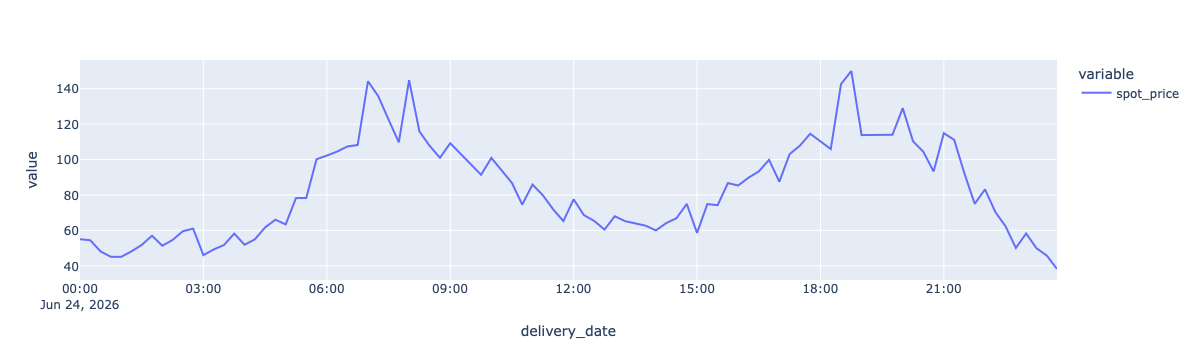

In [ ]:
df.plot()

In [ ]:
keyword = "load"

search_tables(project, dataset_id, keyword)

In [ ]:
table_id = "entsoe_load_forecast_dayahead"

QUERY = f"""
    SELECT delivery_date, load_forecast_dayahead_mw
    FROM `{project}.{dataset_id}.{table_id}`
    WHERE zone = '{zone}'
    AND EXTRACT(DATE from delivery_date) = '{today}'
    ORDER BY delivery_date ASC
"""

df = bq_client.query(QUERY, location="eu").to_dataframe().set_index("delivery_date")
df.index = df.index.tz_convert("Europe/Paris")
df

In [ ]:
df.plot()

In [8]:
import requests
import pandas as pd
from datetime import date, timedelta

def get_helsinki_temperature(start_date='2020-01-01'):
    # Coordonnées géographiques d'Helsinki
    latitude = 60.1695
    longitude = 24.9354
    
    # L'API d'archive a un décalage d'environ 5 jours pour les données consolidées
    end_date = (date.today() - timedelta(days=5)).strftime('%Y-%m-%d')
    
    # Point de terminaison de l'API Historique d'Open-Meteo
    url = "https://archive-api.open-meteo.com/v1/archive"
    
    # Paramètres de la requête
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_mean", # Demande la moyenne journalière à 2m du sol
        "timezone": "Europe/Helsinki"
    }
    
    # Appel à l'API
    response = requests.get(url, params=params)
    
    # Vérification que la requête a fonctionné
    response.raise_for_status()
    
    # Extraction des données JSON
    data = response.json()
    
    # Création du DataFrame pandas
    df = pd.DataFrame({
        'Date': pd.to_datetime(data['daily']['time']),
        'temperature_moyenne': data['daily']['temperature_2m_mean']
    })
    
    # Mettre la date en index pour faciliter les fusions futures avec vos autres données
    df.set_index('Date', inplace=True)
    
    return df

# Exécution
df_meteo = get_helsinki_temperature()

print("--- 5 premières lignes ---")
print(df_meteo.head())

print("\n--- 5 dernières lignes ---")
print(df_meteo.tail())

--- 5 premières lignes ---
            temperature_moyenne
Date                           
2020-01-01                  0.8
2020-01-02                  2.5
2020-01-03                  4.2
2020-01-04                  1.3
2020-01-05                 -1.6

--- 5 dernières lignes ---
            temperature_moyenne
Date                           
2026-06-24                 15.4
2026-06-25                 16.1
2026-06-26                 17.8
2026-06-27                 19.7
2026-06-28                 18.7
